# Education: Socioeconomic Factors and ACT/SAT Performance

## 1. Load and explore the data

### Import libraries
This code imports the libraries used in this section: `numpy` and `pandas` for data handling, and `matplotlib` and `seaborn` for plots. It also sets a clean plotting style.

In [4]:
# Import numpy, pandas, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library liabrary built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

The libraries are loaded and the plotting style is set. There is no output.

### Load the data sets
This code loads the two data sets. The EdGap school identifier is read as an `object` so the 12-digit ID is kept exactly as stored. The NCES file is read with the `unicode_escape` encoding to handle special characters in school names and addresses.

In [7]:
# EdGap data set
edgap = pd.read_excel("../data/EdGap_data.xlsx", 
                      dtype={"NCESSCH School ID": object})

# Load the school information data in pandas
school_information = pd.read_csv("../data/ccd_sch_029_1617_w_1a_11212017.csv", encoding="unicode_escape")

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/worksheet/_read_only.py:81: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
/var/folders/gc/vj3_tr1j2ld4symfmrpzzsch0000gn/T/ipykernel_9506/2862849581.py:6: DtypeWarning: Columns (6,9,14,15,18,19,21,22,25,26,29,31,35,39,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  school_information = pd.read_csv("../data/ccd_sch_029_1617_w_1a_11212017.csv", encoding="unicode_escape")


Both files loaded. The two warnings are harmless here.

### Explore the contents of the data sets
Start by looking at the head of each data frame. This will let us see the names of the columns and a few example values for each column. We can also check whether the data is in tidy format.

print(edgap.head())
print(school_information.head())

The EdGap data has one row per school and seven columns: the school ID, five socioeconomic measures (unemployment rate, share of adults with a college degree, share of children in married-couple families, median household income, and share of students on free or reduced-price lunch), and the school's average ACT score. The shares are stored as proportions between 0 and 1.

The NCES data also has one row per school, with many descriptive columns (names, addresses, grades offered). Both data sets are in tidy format.

This code allows all columns to be displayed and shows the first rows of the NCES data again, so we can see every available column.

In [13]:
pd.set_option("display.max_columns", None)
school_information.head()

,SCHOOL_YEAR,FIPST,STATENAME,ST,SCH_NAME,LEA_NAME,STATE_AGENCY_NO,UNION,ST_LEAID,LEAID,ST_SCHID,NCESSCH,SCHID,MSTREET1,MSTREET2,MSTREET3,MCITY,MSTATE,MZIP,MZIP4,LSTREET1,LSTREET2,LSTREET3,LCITY,LSTATE,LZIP,LZIP4,PHONE,WEBSITE,SY_STATUS,SY_STATUS_TEXT,UPDATED_STATUS,UPDATED_STATUS_TEXT,EFFECTIVE_DATE,SCH_TYPE_TEXT,SCH_TYPE,RECON_STATUS,OUT_OF_STATE_FLAG,CHARTER_TEXT,CHARTAUTH1,CHARTAUTHN1,CHARTAUTH2,CHARTAUTHN2,NOGRADES,G_PK_OFFERED,G_KG_OFFERED,G_1_OFFERED,G_2_OFFERED,G_3_OFFERED,G_4_OFFERED,G_5_OFFERED,G_6_OFFERED,G_7_OFFERED,G_8_OFFERED,G_9_OFFERED,G_10_OFFERED,G_11_OFFERED,G_12_OFFERED,G_13_OFFERED,G_UG_OFFERED,G_AE_OFFERED,GSLO,GSHI,LEVEL,IGOFFERED
0,2016-2017,1,ALABAMA,AL,Sequoyah Sch - Chalkville Campus,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0020,1.000020e+10,100277.0,P O Box 9486,NaN,NaN,Birmingham,AL,35220,NaN,1000 Industrial School Road,NaN,NaN,Birmingham,AL,35220,NaN,(205)680-8574,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
1,2016-2017,1,ALABAMA,AL,Camps,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0050,1.000020e+10,101667.0,P O Box 66,NaN,NaN,Mt Meigs,AL,36057,NaN,1601 County Rd. 57,NaN,NaN,Prattville,AL,36067,NaN,(334)215-3850,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
2,2016-2017,1,ALABAMA,AL,Det Ctr,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0060,1.000020e+10,101670.0,P O Box 66,NaN,NaN,Mt Meigs,AL,36057,NaN,2109 Bashi Rd Bldg 509,NaN,NaN,Thomasville,AL,36784,NaN,(334)215-3850,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
3,2016-2017,1,ALABAMA,AL,Wallace Sch - Mt Meigs Campus,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0030,1.000020e+10,101705.0,P O Box 66,NaN,NaN,Mount Meigs,AL,36057,NaN,1000 Industrial School Road,NaN,NaN,Mount Meigs,AL,36057,NaN,(334)215-6039,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
4,2016-2017,1,ALABAMA,AL,McNeel Sch - Vacca Campus,Alabama Youth Services,1,NaN,AL-210,100002,AL-210-0040,1.000020e+10,101706.0,8950 Roebuck Blvd,NaN,NaN,Birmingham,AL,35206,NaN,8950 Roebuck Blvd,NaN,NaN,Birmingham,AL,35206,NaN,(205)838-4981,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported


All columns of the NCES data are now visible. They include the state, school name, district identifiers, address, school type, charter status, and the grades offered. The school identifier `NCESSCH` is stored as a decimal number and displays in scientific notation.

Use the info method to check the data types, size of the data frame, and numbers of missing values.

In [16]:
edgap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NCESSCH School ID                                7986 non-null   object 
 1   CT Unemployment Rate                             7972 non-null   float64
 2   CT Pct Adults with College Degree                7973 non-null   float64
 3   CT Pct Childre In Married Couple Family          7961 non-null   float64
 4   CT Median Household Income                       7966 non-null   float64
 5   School ACT average (or equivalent if SAT score)  7986 non-null   float64
 6   School Pct Free and Reduced Lunch                7986 non-null   float64
dtypes: float64(6), object(1)
memory usage: 436.9+ KB


The EdGap data has 7,986 schools. The ACT average and the free/reduced lunch percentage have no missing values. Each of the four census-tract variables has a small number of missing values: 14 for unemployment, 13 for college degree, 25 for married couples, and 20 for median income. The school ID is an `object` and all other columns are `float64`.

In [18]:
school_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 65 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   SCHOOL_YEAR          102183 non-null  object 
 1   FIPST                102183 non-null  int64  
 2   STATENAME            102183 non-null  object 
 3   ST                   102183 non-null  object 
 4   SCH_NAME             102183 non-null  object 
 5   LEA_NAME             102183 non-null  object 
 6   STATE_AGENCY_NO      102183 non-null  object 
 7   UNION                2533 non-null    float64
 8   ST_LEAID             102183 non-null  object 
 9   LEAID                102183 non-null  object 
 10  ST_SCHID             102183 non-null  object 
 11  NCESSCH              102181 non-null  float64
 12  SCHID                102181 non-null  float64
 13  MSTREET1             102181 non-null  object 
 14  MSTREET2             1825 non-null    object 
 15  MSTREET3         

The NCES data has 102,183 rows and 65 columns. Only two schools are missing the identifier `NCESSCH`, which is stored as `float64` rather than `object`.

- The school information data set is much larger than the EdGap data set. Clearly the EdGap data set does not include all schools.
- There are missing values in each data set.
- Each data set is in a tidy, or long format.
- The data types for the variables of interest look correct, but the school identifier is an object in the EdGap data set and a float64 in the school information data set.

### Are the data suitable for answering the question?
We want to perform a quick exploratory data analysis to determine whether the data are sufficient to answer our question. If the data are not sufficient, we do not want to waste time doing anything that will not be productive.

The pair plots below show every pairwise relationship in the EdGap data. The school ID is dropped first because it is only a label. First, a basic pair plot: scatter plots for every pair of variables, and the distribution of each variable on the diagonal.

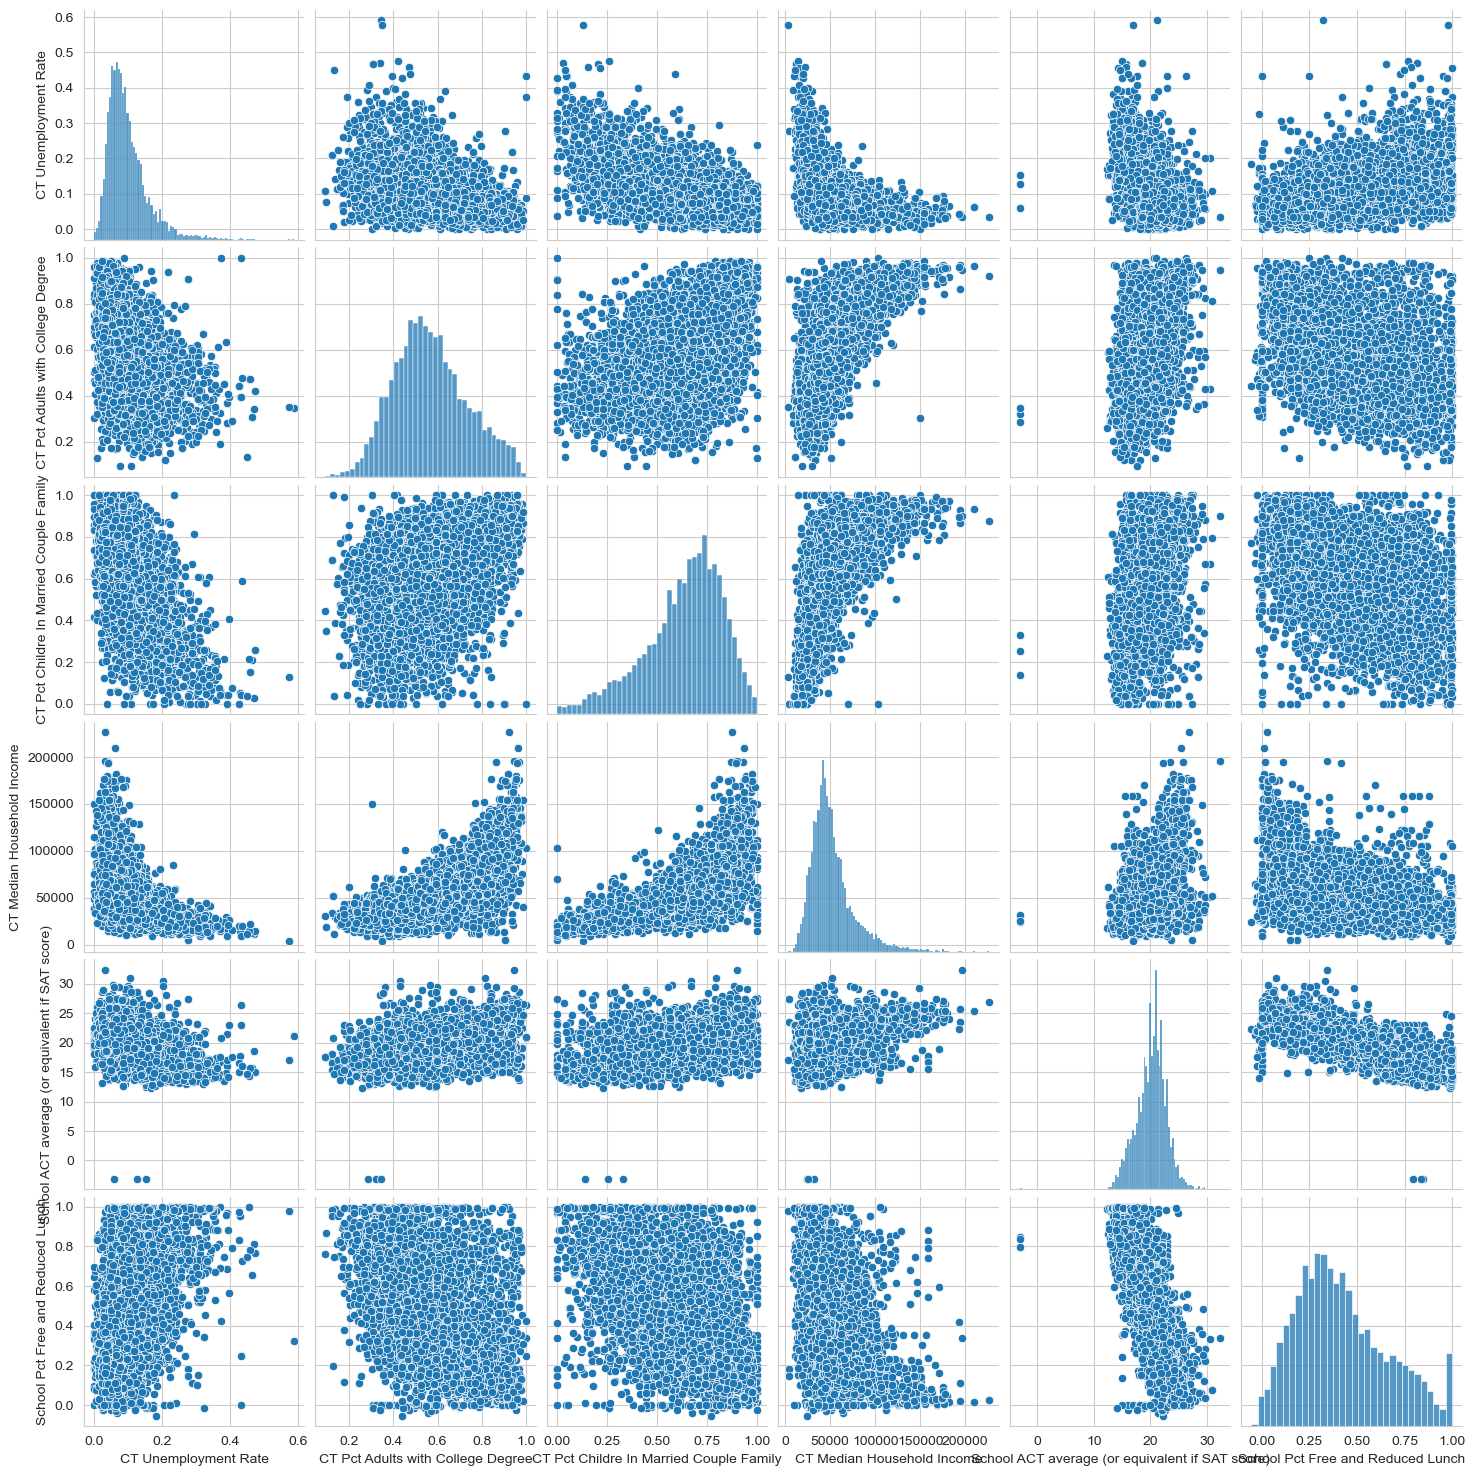

In [23]:
# Pair plot to explore relationships between the variables
sns.pairplot(
    edgap.drop(columns='NCESSCH School ID')
)
plt.show()

The ACT average shows a visible association with each of the other variables. The diagonal histograms show that the ACT average is roughly bell-shaped, while unemployment and income are skewed to the right. A few schools have implausible ACT averages well below 10, which we examine in the data quality section.

Next, add a regression line to every scatter plot and format the axis labels, to make the direction of each relationship easier to see.

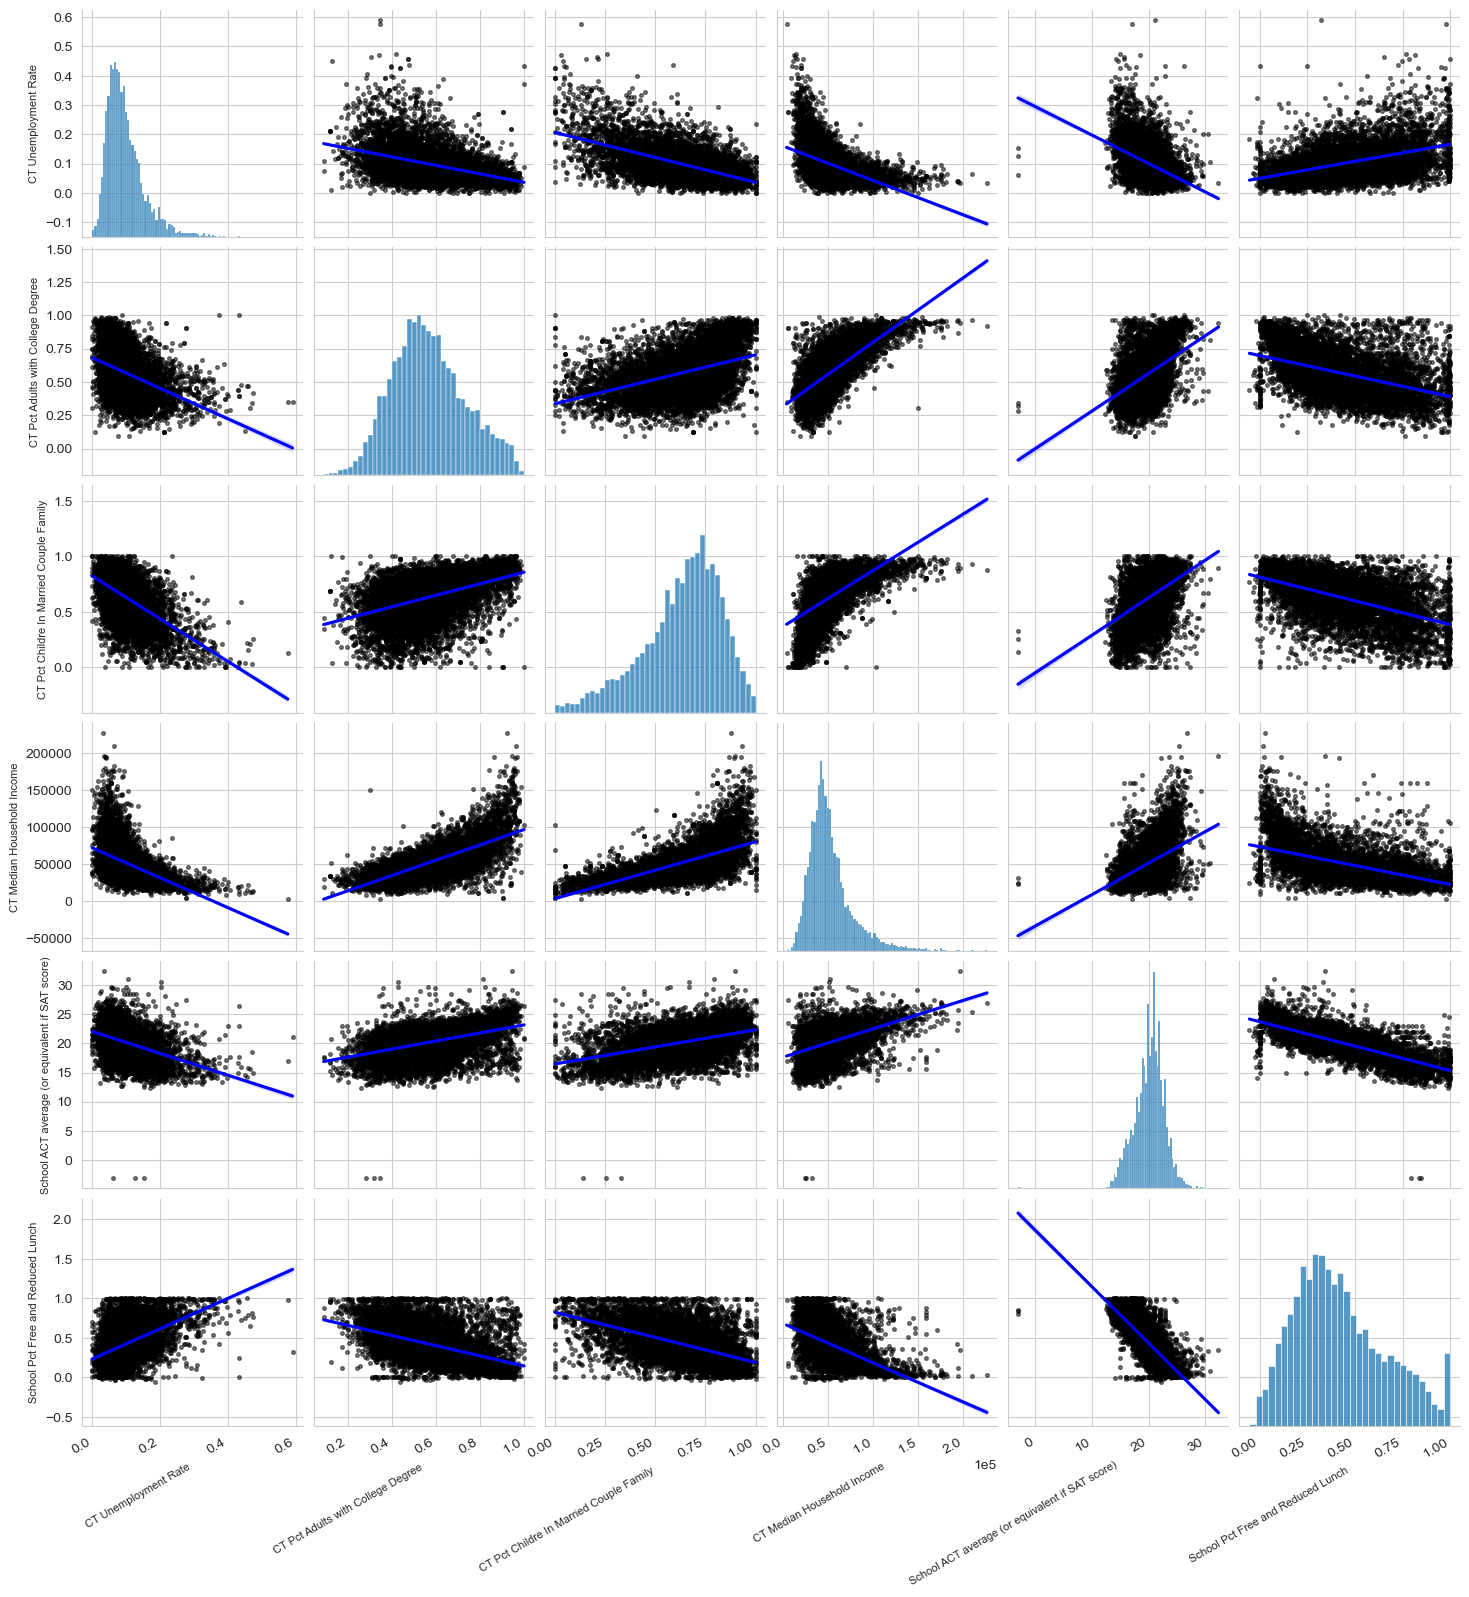

In [26]:
# Add regression lines and format the pair plot
fig = sns.pairplot(
    edgap.drop(columns='NCESSCH School ID'),
    kind="reg",
    plot_kws={
        "line_kws":{"color":"blue"},
        "scatter_kws":{"alpha":0.5,"color":"k","s":7},
    }
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0)) # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right') # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8) # Y-axis label size

   # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    
plt.show()

The regression lines show that the ACT average tends to fall as unemployment and the free/reduced lunch percentage rise, and tends to rise with the percentage of adults with a college degree, the percentage of children in married-couple families, and median household income. The socioeconomic variables are also related to each other: for example, income rises with the percentage of adults with a college degree.

Plot only the row of the pair plot that relates the ACT average to each of the other variables, which is the relationship we care about most.

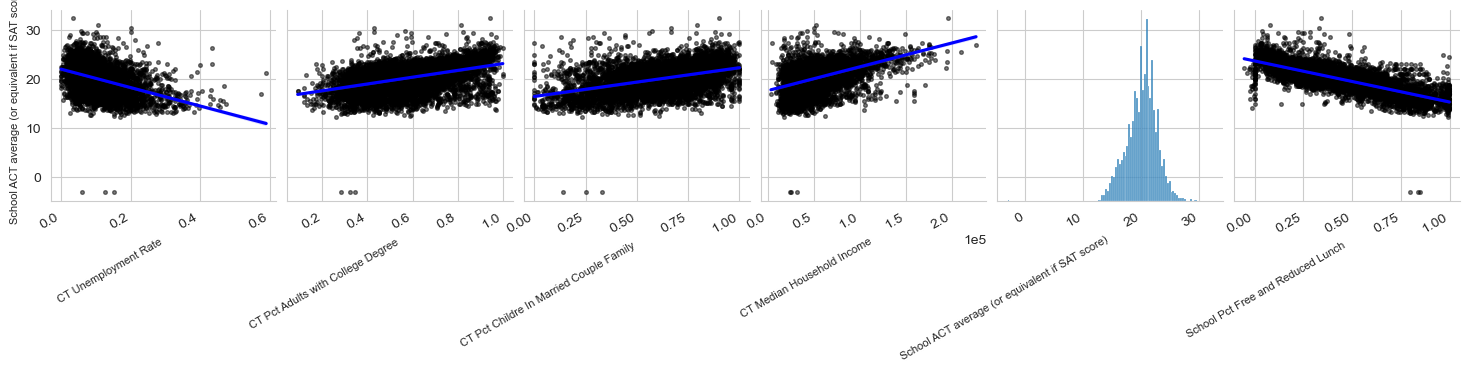

In [29]:
# Plot a single row
fig = sns.pairplot(
    edgap.drop(columns='NCESSCH School ID'),
    y_vars=['School ACT average (or equivalent if SAT score)'],
    kind="reg",
    plot_kws={
        "line_kws":{"color":"blue"},
        "scatter_kws":{"alpha":0.5,"color":"k","s":7},
    }
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0)) # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right') #x=axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8) # Y-axis label size

   # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    
plt.show()

The single row confirms the pattern: the ACT average has a negative relationship with unemployment and with the free/reduced lunch percentage, and a positive relationship with college degree, married-couple families, and income. The relationship with the lunch percentage looks the tightest. A few schools have ACT averages near -3, which is impossible because ACT scores range from 1 to 36.

- There appears to be a relationship between the socioeconomic variables and the ACT score.
- There are some out-of-range ACT and percent lunch values that will need to be dealt with.
- We should have confidence that it is worthwhile to spend time preparing the data for analysis.

### Data preparation
#### Select relevant subsets of the data and rename the columns
The school information data set contains many columns. We will only keep the year, school identity, location, and school type information.

Keep the columns SCHOOL_YEAR, NCESSCH, LSTATE, LZIP, SCH_TYPE_TEXT, LEVEL, CHARTER_TEXT

This code keeps only the seven columns we need from the NCES data and shows the first rows.

In [34]:
school_information = school_information[
    ['SCHOOL_YEAR', 'NCESSCH', 'LSTATE', 'LZIP', 'SCH_TYPE_TEXT', 'LEVEL', 'CHARTER_TEXT']
]
school_information.head()

,SCHOOL_YEAR,NCESSCH,LSTATE,LZIP,SCH_TYPE_TEXT,LEVEL,CHARTER_TEXT
0,2016-2017,1.000020e+10,AL,35220,Alternative School,High,No
1,2016-2017,1.000020e+10,AL,36067,Alternative School,High,No
2,2016-2017,1.000020e+10,AL,36784,Alternative School,High,No
3,2016-2017,1.000020e+10,AL,36057,Alternative School,High,No
4,2016-2017,1.000020e+10,AL,35206,Alternative School,High,No


The NCES data now has only the seven columns we need.

### Rename columns
Rename the columns SCHOOL_YEAR, NCESSCH, LSTATE, LZIP, SCH_TYPE_TEXT, LEVEL, CHARTER_TEXT to year, id, state, zip_code, school_type, school_level, charter

First, rename the EdGap columns to short, descriptive names, using `id` for the school identifier so it matches the NCES data.

In [38]:
edgap=edgap.rename(
    columns={
        "NCESSCH School ID":"id",
        "CT Unemployment Rate":"rate_unemployment",
        "CT Pct Adults with College Degree":"percent_college",
        "CT Pct Childre In Married Couple Family":"percent_married",
        "CT Median Household Income":"median_income",
        "School ACT average (or equivalent if SAT score)":"average_act",
        "School Pct Free and Reduced Lunch":"percent_lunch"
    }
)

In [39]:
school_information=school_information.rename(
    columns={
        "SCHOOL_YEAR":"year",
        "NCESSCH":"id",
        "LSTATE":"state",
        "LZIP":"zip_code",
        "SCH_TYPE_TEXT":"school_type",
        "LEVEL":"school_level",
        "CHARTER_TEXT":"charter"
    }
)

In [40]:
edgap.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


The EdGap columns now have short names, and the values are unchanged.

In [42]:
school_information.head()

,year,id,state,zip_code,school_type,school_level,charter
0,2016-2017,1.000020e+10,AL,35220,Alternative School,High,No
1,2016-2017,1.000020e+10,AL,36067,Alternative School,High,No
2,2016-2017,1.000020e+10,AL,36784,Alternative School,High,No
3,2016-2017,1.000020e+10,AL,36057,Alternative School,High,No
4,2016-2017,1.000020e+10,AL,35206,Alternative School,High,No


The NCES data now uses the same `id` name as the EdGap data, which lets us join the two data sets on this column.

### Join data frames
We want to join the DataFrames using the identity of the school as the key. The identity is given by the NCESSCH school identity. The value is an object in the EdGap data set and a float64 in the school information data set.

We will cast the id column in the school_information DataFrame as an object.

In [45]:
school_information['id'] = school_information['id'].astype('object')

In [46]:
school_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   year          102183 non-null  object
 1   id            102181 non-null  object
 2   state         102183 non-null  object
 3   zip_code      102183 non-null  object
 4   school_type   102181 non-null  object
 5   school_level  102179 non-null  object
 6   charter       102179 non-null  object
dtypes: object(7)
memory usage: 5.5+ MB


The `id` column in the NCES data is now an `object`, the same type as in the EdGap data.

Join the data frames and call the result `df`. We use a left join with the EdGap data on the left, so every EdGap school is kept even if it has no match in the NCES data.

In [49]:
df=edgap.merge(
    school_information,
    how='left',
    on='id'
)

In [50]:
df.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,school_type,school_level,charter
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No


Each EdGap school now has its state, zip code, school type, school level, and charter status attached.

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7986 non-null   object 
 1   rate_unemployment  7972 non-null   float64
 2   percent_college    7973 non-null   float64
 3   percent_married    7961 non-null   float64
 4   median_income      7966 non-null   float64
 5   average_act        7986 non-null   float64
 6   percent_lunch      7986 non-null   float64
 7   year               7898 non-null   object 
 8   state              7898 non-null   object 
 9   zip_code           7898 non-null   object 
 10  school_type        7898 non-null   object 
 11  school_level       7898 non-null   object 
 12  charter            7898 non-null   object 
dtypes: float64(6), object(7)
memory usage: 811.2+ KB


The joined data has 7,986 rows and 13 columns, the same number of rows as the EdGap data, as expected for a left join. Only 7,898 schools have NCES information, so 88 EdGap schools did not match any school in the NCES file. Those schools have missing values in the NCES columns.

### Quality control
There are natural bounds for the numerical variables in the data set. Check the minimum and maximum values in each column. We can use the describe() method to compute descriptive statistics.

In [55]:
df.describe()

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch
count,7972.000000,7973.000000,7961.000000,7966.000000,7986.000000,7986.000000
mean,0.098730,0.568930,0.633440,52026.905222,20.181532,0.420651
std,0.058959,0.165704,0.196764,24228.057079,2.595201,0.239754
min,0.000000,0.091493,0.000000,3589.000000,-3.070818,-0.054545
25%,0.058655,0.450828,0.523810,36597.250000,18.600000,0.238501
50%,0.085649,0.554979,0.667594,46833.500000,20.400000,0.381570
75%,0.123376,0.676571,0.777135,61369.250000,21.910867,0.575447
max,0.590278,1.000000,1.000000,226181.000000,32.362637,0.998729


Most variables are within their natural bounds. The ACT average has a minimum of about -3.07, and the lunch percentage has a minimum of about -0.05. Both are impossible: ACT scores range from 1 to 36, and a percentage cannot be negative. The mean ACT average is about 20.2 and the mean lunch share is about 42%.

Use the minimum and maximum of each numerical column to check the bounds more directly.

In [58]:
df.select_dtypes(include=['number']).agg(['min','max']).round(2)

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch
min,0.00,0.09,0.0,3589.0,-3.07,-0.05
max,0.59,1.00,1.0,226181.0,32.36,1.00


The unemployment rate, college degree share, and married-couple share are between 0 and 1, as they should be. Median income ranges from about 3,600 to about 226,000 USD, which is wide but plausible for census tracts. The negative ACT and lunch values are the only values outside their natural bounds.

Set the out-of-range values to missing so they are not treated as real measurements: ACT averages below 1 and negative lunch percentages.

In [61]:
# Set out-of-range values to NaN using np.nan
df.loc[df['percent_lunch']<0,'percent_lunch']= np.nan
df.loc[df['average_act']<1,'average_act']= np.nan

The impossible values are now missing.

Check the types, levels, and charter status of the schools, to decide which schools belong in the analysis.

In [64]:
print(df['school_type'].value_counts())
print(df['school_level'].value_counts())
print(df['charter'].value_counts())

school_type
Regular School                 7885
Alternative School               10
Special Education School          2
Career and Technical School       1
Name: count, dtype: int64
school_level
High            7230
Other            631
Not reported      35
Elementary         2
Name: count, dtype: int64
charter
No                7329
Yes                352
Not applicable     217
Name: count, dtype: int64


Almost all schools (7,885 of 7,898) are regular schools. By level, 7,230 are high schools, 631 are "Other", 35 are "Not reported", and 2 are elementary schools. For charter status, 7,329 are not charter schools, 352 are charter schools, and 217 are "Not applicable". Charter schools are a small share of the sample.

We are interested in high schools, so keep only schools whose level is "High". This also removes the 88 schools that had no NCES information, because their level is missing.

In [67]:
# Keep only the high schools
df=df.loc[df['school_level']=='High']

In [68]:
# Check for any duplicated rows
df.duplicated().sum()

0

The count is 0, so there are no duplicated rows.

### Identify missing value
How many values of each variables are missing?

In [71]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,12
percent_college,11
percent_married,20
median_income,16
average_act,3
percent_lunch,20
year,0
state,0
zip_code,0


Among the high schools, the missing values are in the socioeconomic variables: 12 for unemployment, 11 for college degree, 20 for married couples, 16 for median income, and 20 for the lunch percentage. Three schools are missing the ACT average (the impossible negative values we set to missing).

Express the missing values as a percentage of all high schools to judge how serious the problem is.

In [74]:
percent_missing = df.isna().mean().round(4) * 100
percent_missing.to_frame(name="Percent Missing Values")

,Percent Missing Values
id,0.00
rate_unemployment,0.17
percent_college,0.15
percent_married,0.28
median_income,0.22
average_act,0.04
percent_lunch,0.28
year,0.00
state,0.00
zip_code,0.00


No variable is missing more than 0.3% of its values, so missing data is a very small problem in this data set.

What states do we have data from?

In [77]:
df['state'].value_counts()

state
TX    913
OH    654
IL    564
PA    543
MI    498
NC    407
FL    404
GA    367
WI    351
NJ    341
MO    337
IN    321
NY    295
TN    265
WA    263
MA    253
KY    198
LA    194
WY     38
DE     24
Name: count, dtype: int64

Texas has the most schools (913), followed by Ohio (654), Illinois (564), Pennsylvania (543), and Michigan (498). Wyoming (38) and Delaware (24) have the fewest.

Count how many different states appear in the data.

In [80]:
df['state'].nunique()

20

The data come from only 20 states, far fewer than the 50 states in the country.

Plot the number of schools in each state on a map of the United States.

In [83]:
# Import libraries
import plotly.offline as po
import plotly.graph_objs as pg

In [84]:
# Draw the map. States that have no schools in the data are left blank.
layout = dict(
    geo={"scope":"usa"}, coloraxis_colorbar=dict(title="Number of Schools")
)
data = dict(
    type="choropleth",
    locations=df["state"].value_counts().index,
    locationmode="USA-states",
    z=df["state"].value_counts().values,
    coloraxis="coloraxis"
)

x=pg.Figure(data=[data],layout=layout)
po.iplot(x)

The map shows schools spread across the Midwest, Northeast, and South, with only two western states (Washington and Wyoming).

We are missing a large amount of USA data due to omission. This is not evident by examining NaN values in the data set.

We could obtain this information from public records, but we will not do that here. Because 30 states are absent, any conclusions apply only to the states in the data, and may not generalize to the whole country.

Drop the rows where the average ACT score is missing

In [88]:
df=df.dropna(subset=['average_act'])

The 3 schools without an ACT average are removed, leaving 7,227 schools.

In [90]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,12
percent_college,11
percent_married,20
median_income,16
average_act,0
percent_lunch,20
year,0
state,0
zip_code,0


The ACT average no longer has missing values. The remaining missing values are in the predictor variables, which we handle next.

### Data imputation
Define the predictor variables to be rate_unemployment, percent_college, percent_married, median_income, percent_lunch, state, and charter

In [93]:
predictor_variables = [
    'rate_unemployment',
    'percent_college',
    'percent_married',
    'median_income',
    'percent_lunch',
    'state',
    'charter'
]

Use the iterative imputer to replace missing values in the columns corresponding to predictor variables in the analysis

In [95]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [96]:
imputer = IterativeImputer()

Fit the imputer using the numerical predictor variables (this can include dummies for categorical variables)

In [98]:
# Define the columns you want to use in the imputation process
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()
print(numerical_predictors)

['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch']


Five predictors are numerical: unemployment rate, college degree share, married-couple share, median income, and lunch percentage. The other two predictors, state and charter status, are categories and have no missing values.

In [100]:
# Fit the imputer
imputer.fit(df.loc[:,numerical_predictors])

IterativeImputer()

The imputer has learned how the numerical predictors relate to each other.

Replace the missing values in the numerical predictors with the imputed values.

In [103]:
df.loc[:,numerical_predictors] = imputer.transform(df.loc[:,numerical_predictors])

In [104]:
# Check for missing values
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,0
percent_college,0
percent_married,0
median_income,0
average_act,0
percent_lunch,0
year,0
state,0
zip_code,0


Every column now has 0 missing values, so the data set is complete and ready for analysis.

### Export the clean data set

In [107]:
df.to_csv(
    '../data/education_clean.csv',
    encoding='utf-8-sig',
    index=False
)

The clean data set is saved as `education_clean.csv`.

## 2. Exploratory Data Analysis

### Import libraries
This code imports the libraries for this section. `matplotlib` and `seaborn` are used for plots now; the preprocessing, `statsmodels`, and `scikit-learn` metric imports are for the modeling that follows the exploration.

In [111]:
# Import numpy, pandas, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library liabrary built on matplotlib
import seaborn as sns

# Set the plotting style
sns.set_style("whitegrid")

# Model preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm

### Load clean data

In [113]:
df = pd.read_csv("/Users/giang/Documents/Data science projects/education/data/education_clean.csv")

In [114]:
df.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,school_type,school_level,charter
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No


The data has the same 13 columns as before: the school ID, the five socioeconomic variables, the ACT average, and the year, state, zip code, school type, school level, and charter status. Reading the CSV turns the ID and zip code into plain numbers. Zip codes that start with 0 may lose the leading zero, which does not matter here because we do not use zip codes in the analysis.

### Examine distributions and relationships

Plot the correlation matrix of the numerical variables in the training data to explore relationships between the variables.

Each cell of the heatmap shows the correlation between two variables, from -1 (perfect negative) to 1 (perfect positive).

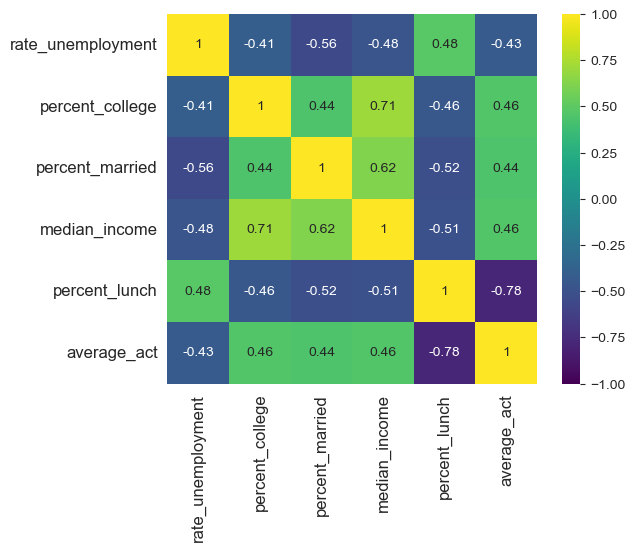

In [118]:
predictor_variables = [
    'rate_unemployment',
    'percent_college',
    'percent_married',
    'median_income',
    'percent_lunch',
    'state',
    'charter'
]
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

corr_matrix = df[numerical_predictors +["average_act"]].corr()

sns.heatmap(
    corr_matrix, vmax= 1, vmin = -1, square = True, annot = True, cmap = "viridis"
)

plt.tick_params(labelsize=12)

plt.show()

The free/reduced lunch percentage has the strongest relationship with the ACT average (correlation -0.78): schools with more students on subsidized lunch tend to have lower ACT averages. College degree share (0.46), median income (0.46), and married-couple share (0.44) are moderately positively related to the ACT average, and unemployment is moderately negatively related (-0.43).

The predictors are also correlated with each other. The strongest are college degree share with median income (0.71) and median income with married-couple share (0.62). Because the predictors overlap, we should be careful when interpreting the effect of any single predictor in a regression model.

Make pair plots to explore relationships between the variables. The pair plots below use a separate color for each charter status and format the axis labels.

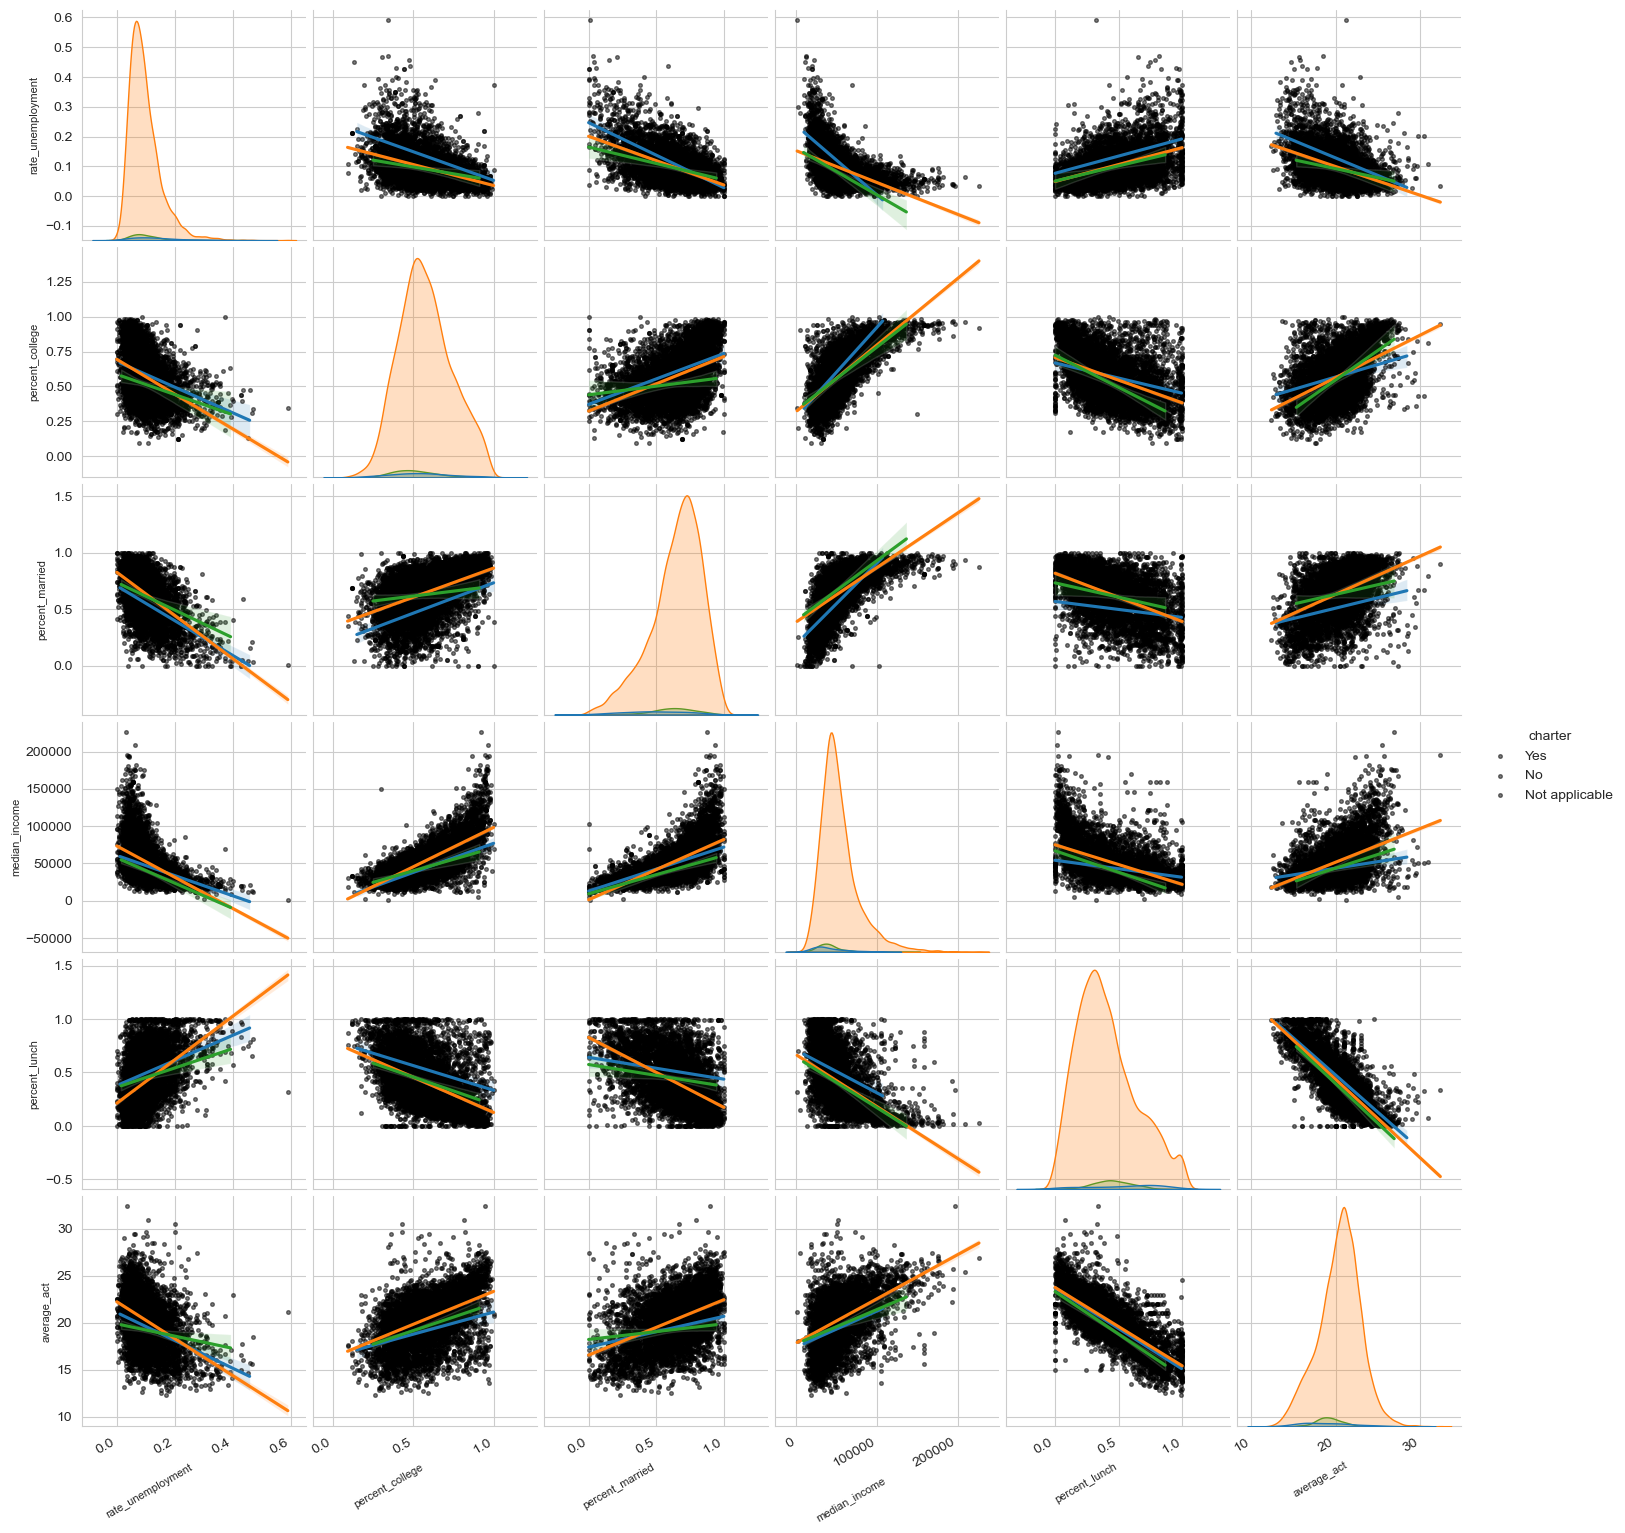

In [121]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors + ['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={
        "scatter_kws":{"alpha": 0.5, "color":"k", "s": 7},
    }
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci',axis='x',scilimits=(0,0)) # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right') # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8) # Y-axis label size

   # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.show()

The cleaned data show the same relationships as before, and the impossible ACT values near -3 are gone. For each of the three charter groups, the ACT average falls with unemployment and lunch percentage and rises with college degree share, married-couple share, and income. The slopes differ somewhat between groups, but charter schools and "Not applicable" schools are far fewer than non-charter schools, so their lines are less certain. The regression lines also extend past possible values (for example, negative income), which is only an artifact of drawing a straight line.

#### Identify outliers

We can use the interquartile range to identify outliers. This is also evident in boxplots of the data. Median income is on a very different scale than the other predictors, so we will make two plots to explore the data.

The first plot shows the four predictors that are proportions between 0 and 1.

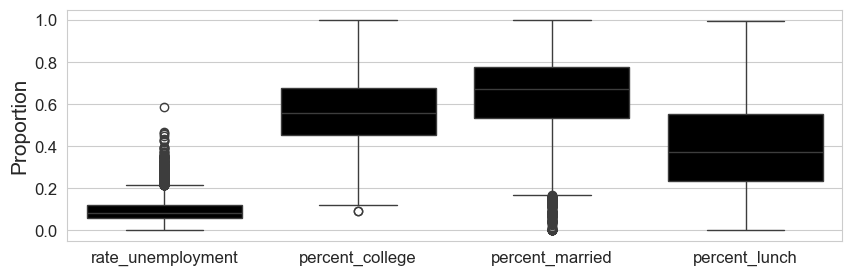

In [126]:
plt.figure(figsize=(10,3))

fractions = list(numerical_predictors)
fractions.remove('median_income')

sns.boxplot(data=df[fractions], color='k')
plt.ylabel('Proportion', fontsize=15)
plt.tick_params(labelsize=12)
               
plt.show()

Unemployment is skewed to the right, with many schools in communities with unemployment above about 0.2. The married-couple share is skewed to the left, with many schools below about 0.17. The college degree share has one low outlier near 0.09, and the lunch percentage has no outliers. These extreme values look like real communities (for example, areas with very high unemployment) rather than errors, so there is no reason to remove them.

The second plot shows median income, which is on a dollar scale.

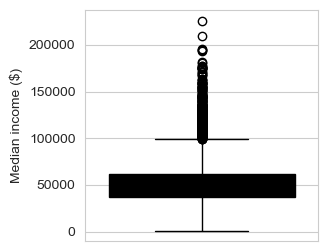

In [129]:
plt.figure(figsize=(3,3))
sns.boxplot(data=df, y='median_income', color='k')
plt.ylabel('Median income ($)')

plt.show()

Median income is skewed to the right: most schools are in tracts with a median income under about 100,000 USD, and many wealthier tracts appear as outliers, with the highest above 200,000 USD. These are plausible high-income communities, so they are kept in the data.

## 3. Research question and initial analysis

### Research question
**Do charter high schools have lower average ACT/SAT scores than non-charter public high schools, and how much of any difference is explained by the socioeconomic characteristics of the communities they serve?**

*Why it matters:* Charter schools are publicly funded schools that operate independently of the traditional district system. If they score lower, that could mean they serve students who face more disadvantages, or that something about the schools themselves matters. Separating the two is a question about equality of educational opportunity.

*Hypothesis:* Charter high schools have a lower average ACT score than non-charter high schools, but most of that gap is explained by the lower socioeconomic status of the communities where they are located. Once we account for the five socioeconomic variables, the remaining difference should be small.

*Data:* The ACT scores and the socioeconomic variables come from the EdGap data, and the charter status comes from the `charter` column of the NCES school information data, which is joined to the EdGap data above. No additional data set is used.

*Approach:* This is mainly a descriptive and diagnostic analysis: first compare the two groups of schools, then estimate the charter difference with and without accounting for socioeconomic variables.

#### Select the schools to compare
Keep only schools that are clearly charter ("Yes") or non-charter ("No"). Schools with charter status "Not applicable" are left out because they belong to neither group. This code also creates an indicator column, `is_charter`, equal to 1 for charter schools and 0 otherwise, for use in the model later. It then counts the schools in each group.

In [134]:
df_charter = df.loc[df['charter'].isin(['Yes', 'No'])].copy()
df_charter['is_charter'] = (df_charter['charter'] == 'Yes').astype(int)
df_charter['charter'].value_counts()

charter
No     6858
Yes     170
Name: count, dtype: int64

The comparison uses 7,028 high schools: 6,858 non-charter and only 170 charter schools (about 2.4%). The 199 schools with "Not applicable" status are excluded. The charter group is small, so estimates for it will be less precise than for non-charter schools.

#### Compare average ACT scores
Summarize the distribution of the average ACT score for each group of schools.

In [137]:
df_charter.groupby('charter')['average_act'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
charter,,,,,,,,
No,6858.0,20.36,2.50,12.36,18.90,20.60,22.00,32.36
Yes,170.0,19.02,3.14,12.90,16.59,18.89,21.12,28.40


Charter schools have a lower average ACT score. The mean is 19.02 for charter schools versus 20.36 for non-charter schools, a raw gap of about 1.3 points, and the median gap is even larger (18.89 versus 20.60). Charter schools are also more spread out (standard deviation 3.14 versus 2.50). The distributions still overlap a great deal: the charter schools' middle half runs from about 16.6 to 21.1, while the non-charter schools' runs from about 18.9 to 22.0.

Show the same comparison as a boxplot.

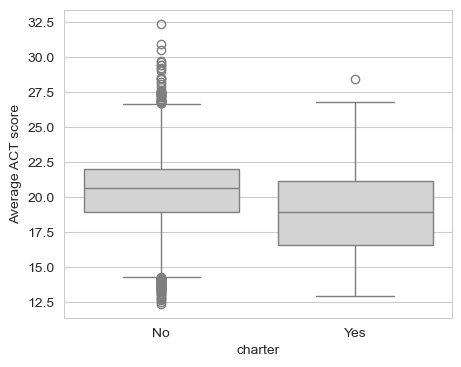

In [140]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=df_charter, x='charter', y='average_act', order=['No', 'Yes'], color='lightgray')
plt.ylabel('Average ACT score')

plt.show()

The boxplot shows the same pattern. The charter box sits lower and is taller, and the whiskers of the two groups overlap. Many charter schools score as high as typical non-charter schools, even though the average is lower.

#### Compare the communities the schools serve
If charter schools tend to be in more disadvantaged communities, that could explain part of their lower scores. This code compares the average of each socioeconomic variable for the two groups.

In [143]:
socioeconomic_variables = ['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch']
df_charter.groupby('charter')[socioeconomic_variables].mean().round(3).T

charter,No,Yes
rate_unemployment,0.095,0.139
percent_college,0.575,0.551
percent_married,0.645,0.492
median_income,53356.946,41810.166
percent_lunch,0.406,0.541


Charter schools are in communities with greater socioeconomic disadvantage on four of the five measures. Compared with non-charter schools, the census tracts of charter schools have higher unemployment (13.9% versus 9.5%), lower median household income (about 41,800 USD versus 53,400 USD), a smaller share of children in married-couple families (49% versus 65%), and a larger share of students on free or reduced-price lunch (54% versus 41%). The share of adults with a college degree is similar (55% versus 58%).

Show the distribution of each socioeconomic variable for the two groups.

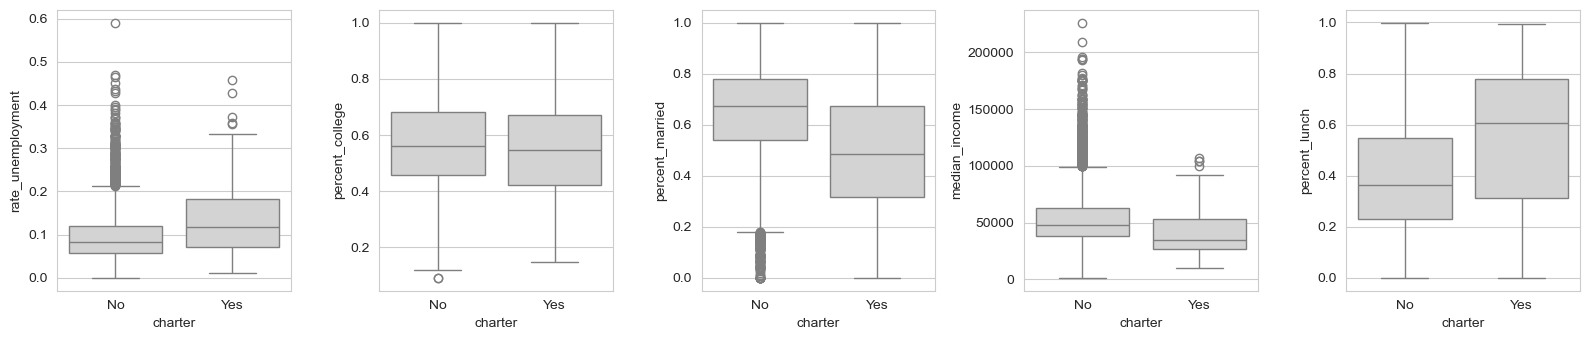

In [146]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for axis, variable in zip(axes, socioeconomic_variables):
    sns.boxplot(data=df_charter, x='charter', y=variable, order=['No', 'Yes'], color='lightgray', ax=axis)
plt.tight_layout()

plt.show()

The boxplots confirm that the differences are not driven by a few extreme schools. The whole distribution for charter schools is shifted toward higher unemployment, lower income, fewer married-couple families, and a higher lunch percentage, while the college degree distributions are close. This supports the hypothesis that charter schools in this data serve more disadvantaged communities.

#### Does the relationship between lunch percentage and ACT score differ by charter status?
The free/reduced lunch percentage had the strongest relationship with the ACT average (correlation -0.78). This plot draws a regression line for each group, with charter schools drawn on top. If the lines are about the same, charter and non-charter schools with similar lunch percentages have similar scores.

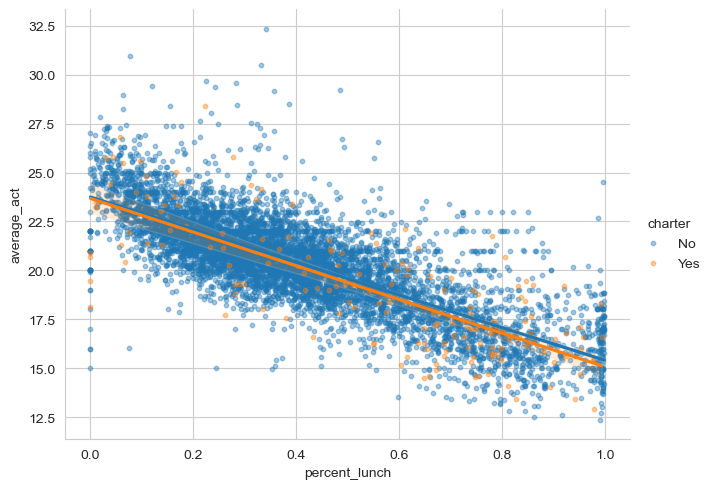

In [149]:
sns.lmplot(
    data=df_charter,
    x='percent_lunch',
    y='average_act',
    hue='charter',
    hue_order=['No', 'Yes'],
    scatter_kws={'alpha': 0.4, 's': 10},
    height=5,
    aspect=1.3,
)
plt.show()

The two regression lines nearly coincide. Charter schools are mostly found at higher lunch percentages (toward the right), where scores are lower for both groups, rather than sitting below the line for non-charter schools. At the same lunch percentage, charter and non-charter schools score about the same.

#### Preliminary statistical model
Estimate the charter difference using linear regression (ordinary least squares) with the average ACT score as the outcome. Three models show how the estimate changes as we account for more information:
1. No controls: only the charter indicator, which reproduces the raw gap.
2. Socioeconomic controls: adds the five socioeconomic variables.
3. Socioeconomic controls + state: also adds state, because states differ in school policies and in how many charter schools they have.

The table shows the coefficient on `is_charter` (the estimated difference in average ACT score for charter schools), its 95% confidence interval, its p-value, and the R-squared of each model.

In [152]:
socioeconomic_controls = ' + '.join(socioeconomic_variables)

charter_models = {
    'No controls': smf.ols('average_act ~ is_charter', data=df_charter).fit(),
    'Socioeconomic controls': smf.ols(f'average_act ~ is_charter + {socioeconomic_controls}', data=df_charter).fit(),
    'Socioeconomic controls + state': smf.ols(f'average_act ~ is_charter + {socioeconomic_controls} + C(state)', data=df_charter).fit(),
}

charter_results = pd.DataFrame(
    {
        'Charter coefficient': [model.params['is_charter'] for model in charter_models.values()],
        '95% CI lower': [model.conf_int().loc['is_charter', 0] for model in charter_models.values()],
        '95% CI upper': [model.conf_int().loc['is_charter', 1] for model in charter_models.values()],
        'p-value': [model.pvalues['is_charter'] for model in charter_models.values()],
        'R-squared': [model.rsquared for model in charter_models.values()],
    },
    index=charter_models.keys(),
).round(3)
charter_results

,Charter coefficient,95% CI lower,95% CI upper,p-value,R-squared
No controls,-1.341,-1.724,-0.958,0.000,0.007
Socioeconomic controls,-0.186,-0.423,0.051,0.124,0.628
Socioeconomic controls + state,-0.095,-0.318,0.127,0.401,0.678


Without controls, charter schools score 1.34 ACT points lower (95% confidence interval -1.72 to -0.96, p < 0.001), which matches the raw gap. Once the socioeconomic variables are included, the estimated difference shrinks to -0.19 points, and it is no longer statistically distinguishable from zero (interval -0.42 to 0.05, p = 0.12). Adding state brings it to -0.10 (interval -0.32 to 0.13, p = 0.40). The socioeconomic variables also explain far more of the variation in scores than charter status does: R-squared rises from 0.007 to 0.628 (0.678 with state).

In this data, most of the raw charter gap is therefore accounted for by the socioeconomic characteristics of the communities the schools serve, which is consistent with the hypothesis.

Next step is using the same two data sets, examine the charter difference separately by state, test whether the relationship between the lunch percentage and the ACT score differs for charter and non-charter schools (an interaction term), and check the model assumptions (for example, the residuals).